In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv(r"C:\Calibo\ecommerce_customer.csv")
df

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD100995,C1410,2025-07-13,NaN,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3050,ORD101148,C1685,2025-10-08,47.0,Premium,Delhi,East,Grocery,Novel,Mobile App,...,11.5,9,8,4.4,1111.95,313.24,798.71,646.78,151.93,19.02
3051,ORD102155,C1641,2025-09-15,27.0,Regular,Bengaluru,North,Home Appliances,Novel,Online,...,11.0,13,5,5.0,329.51,31.67,297.84,252.38,45.46,15.26
3052,ORD101767,C1457,2025-07-04,35.0,Premium,Bengaluru,East,Sports,Shirt,Store,...,9.5,6,4,3.1,20073.84,3894.32,16179.52,13306.36,2873.16,17.76
3053,ORD101123,C1789,2025-04-09,39.0,Occasional,Kochi,West,Sports,Shoes,Online,...,32.4,7,6,3.4,274.47,44.74,229.73,163.04,66.69,29.03


In [4]:
df.head()

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD100995,C1410,2025-07-13,NaN,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31


In [5]:
df.tail()

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
3050,ORD101148,C1685,2025-10-08,47.0,Premium,Delhi,East,Grocery,Novel,Mobile App,...,11.5,9,8,4.4,1111.95,313.24,798.71,646.78,151.93,19.02
3051,ORD102155,C1641,2025-09-15,27.0,Regular,Bengaluru,North,Home Appliances,Novel,Online,...,11.0,13,5,5.0,329.51,31.67,297.84,252.38,45.46,15.26
3052,ORD101767,C1457,2025-07-04,35.0,Premium,Bengaluru,East,Sports,Shirt,Store,...,9.5,6,4,3.1,20073.84,3894.32,16179.52,13306.36,2873.16,17.76
3053,ORD101123,C1789,2025-04-09,39.0,Occasional,Kochi,West,Sports,Shoes,Online,...,32.4,7,6,3.4,274.47,44.74,229.73,163.04,66.69,29.03
3054,ORD101347,C1040,2025-11-09,24.0,Regular,Kochi,Central,Home Appliances,Laptop,Marketplace,...,7.3,13,6,3.1,5554.28,525.99,5028.29,2927.82,2100.47,41.77


In [6]:
df.shape

(3055, 32)

In [7]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Customer_Age',
       'Customer_Segment', 'City', 'Region', 'Category', 'Product_Name',
       'Sales_Channel', 'Payment_Method', 'Device', 'Quantity', 'Unit_Price',
       'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating',
       'Return_Status', 'Order_Status', 'Marketing_Source',
       'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed',
       'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount',
       'Discount_Amount', 'Net_Sales', 'Estimated_Cost', 'Profit',
       'Profit_Margin_Pct'],
      dtype='object')

In [8]:
df.dtypes

Order_ID                    object
Customer_ID                 object
Order_Date                  object
Customer_Age               float64
Customer_Segment            object
City                        object
Region                      object
Category                    object
Product_Name                object
Sales_Channel               object
Payment_Method              object
Device                      object
Quantity                     int64
Unit_Price                 float64
Discount_Pct               float64
Shipping_Days              float64
Customer_Rating            float64
Delivery_Rating            float64
Return_Status               object
Order_Status                object
Marketing_Source            object
Customer_Loyalty_Points    float64
Website_Session_Minutes    float64
Items_Viewed                 int64
Previous_Orders              int64
Customer_Satisfaction      float64
Gross_Amount               float64
Discount_Amount            float64
Net_Sales           

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 3055 non-null   object 
 1   Customer_ID              3055 non-null   object 
 2   Order_Date               3055 non-null   object 
 3   Customer_Age             2932 non-null   float64
 4   Customer_Segment         3055 non-null   object 
 5   City                     2979 non-null   object 
 6   Region                   3055 non-null   object 
 7   Category                 3055 non-null   object 
 8   Product_Name             3055 non-null   object 
 9   Sales_Channel            3055 non-null   object 
 10  Payment_Method           2978 non-null   object 
 11  Device                   3055 non-null   object 
 12  Quantity                 3055 non-null   int64  
 13  Unit_Price               2962 non-null   float64
 14  Discount_Pct            

In [10]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
count,2932.000000,3055.000000,2962.00000,2902.000000,2948.000000,2840.000000,3055.000000,2930.000000,2979.000000,3055.000000,3055.000000,2901.000000,2962.000000,2810.000000,2810.000000,2810.000000,2810.000000,2809.000000
mean,35.328104,3.248773,1583.13266,15.407105,4.550543,3.745070,3.673355,872.558362,14.699094,7.062848,5.006219,3.669424,5171.610665,786.158598,4411.498904,3153.257843,1258.241060,28.377437
std,11.316398,1.861875,2366.58516,10.502571,2.288896,0.777563,0.838132,629.154614,9.540359,2.678465,2.276333,0.842385,8994.240302,1681.951220,7595.452348,5346.688134,2529.055858,9.427132
min,-13.000000,-2.000000,12.75000,-10.000000,-3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-7620.860000,-780.380000,-6840.480000,-5446.480000,-1394.000000,12.040000
25%,28.000000,2.000000,468.92250,8.250000,3.000000,3.200000,3.100000,363.000000,7.900000,5.000000,3.000000,3.100000,1214.615000,107.150000,1020.622500,723.547500,263.065000,20.280000
50%,35.000000,3.000000,923.14500,14.895000,4.000000,3.800000,3.700000,834.500000,12.700000,7.000000,5.000000,3.700000,2640.185000,327.825000,2286.520000,1613.435000,611.055000,28.230000
75%,42.250000,4.000000,1878.94250,21.670000,6.000000,4.300000,4.300000,1294.000000,19.450000,9.000000,6.000000,4.300000,5730.980000,834.957500,4841.167500,3504.470000,1318.835000,36.400000
max,102.000000,40.000000,61182.50000,120.000000,35.000000,9.000000,5.000000,2970.000000,96.100000,18.000000,13.000000,5.000000,244730.000000,45519.780000,199210.220000,109806.220000,89404.000000,44.980000


In [11]:
df['Payment_Method'].value_counts()

Payment_Method
UPI            546
Net Banking    502
Credit Card    495
Debit Card     473
Wallet         469
Cash           458
CASH            11
NET BANKING     11
WALLET           5
CREDIT CARD      5
DEBIT CARD       3
Name: count, dtype: int64

In [12]:
df['Payment_Method'] = np.where(
    df['Payment_Method'].notna(),
    df['Payment_Method'].str.strip().str.title(),
    df['Payment_Method']
)

In [13]:
df['Payment_Method'].value_counts()

Payment_Method
Upi            546
Net Banking    513
Credit Card    500
Debit Card     476
Wallet         474
Cash           469
Name: count, dtype: int64

In [14]:
df['Category'].value_counts()

Category
Home Appliances      428
Sports               389
Electronics          371
Grocery              371
Furniture            366
Beauty               365
Fashion              357
Books                348
 Books                10
 Home Appliances      10
 Sports                9
 Grocery               8
 Fashion               7
 Electronics           7
 Furniture             5
 Beauty                4
Name: count, dtype: int64

In [15]:
df['Category'] = np.where(
    df['Category'].notna(),
    df['Category'].str.strip().str.title(),
    df['Category']
)

In [16]:
df['Category'].value_counts()

Category
Home Appliances    438
Sports             398
Grocery            379
Electronics        378
Furniture          371
Beauty             369
Fashion            364
Books              358
Name: count, dtype: int64

In [17]:
df['City'].value_counts()

City
Chennai       308
Kochi         299
Delhi         296
Coimbatore    295
Kolkata       293
Mumbai        291
Hyderabad     290
Pune          281
Bengaluru     278
Jaipur        257
bengaluru      15
chennai        13
mumbai         11
pune           10
hyderabad       9
delhi           8
kolkata         8
kochi           8
coimbatore      7
jaipur          2
Name: count, dtype: int64

In [18]:
df['City'] = np.where(
    df['City'].notna(),
    df['City'].str.strip().str.title(),
    df['City']
)

In [19]:
df['City'].value_counts()

City
Chennai       321
Kochi         307
Delhi         304
Coimbatore    302
Mumbai        302
Kolkata       301
Hyderabad     299
Bengaluru     293
Pune          291
Jaipur        259
Name: count, dtype: int64

In [20]:
df.duplicated().sum()

np.int64(50)

In [21]:
df = df.drop_duplicates()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.isna().sum()

Order_ID                     0
Customer_ID                  0
Order_Date                   0
Customer_Age               120
Customer_Segment             0
City                        75
Region                       0
Category                     0
Product_Name                 0
Sales_Channel                0
Payment_Method              75
Device                       0
Quantity                     0
Unit_Price                  90
Discount_Pct               151
Shipping_Days              105
Customer_Rating            209
Delivery_Rating              0
Return_Status                0
Order_Status                 0
Marketing_Source             0
Customer_Loyalty_Points    121
Website_Session_Minutes     75
Items_Viewed                 0
Previous_Orders              0
Customer_Satisfaction      151
Gross_Amount                90
Discount_Amount            240
Net_Sales                  240
Estimated_Cost             240
Profit                     240
Profit_Margin_Pct          241
dtype: i

In [24]:
df.isna().sum()[df.isna().sum() > 0]

Customer_Age               120
City                        75
Payment_Method              75
Unit_Price                  90
Discount_Pct               151
Shipping_Days              105
Customer_Rating            209
Customer_Loyalty_Points    121
Website_Session_Minutes     75
Customer_Satisfaction      151
Gross_Amount                90
Discount_Amount            240
Net_Sales                  240
Estimated_Cost             240
Profit                     240
Profit_Margin_Pct          241
dtype: int64

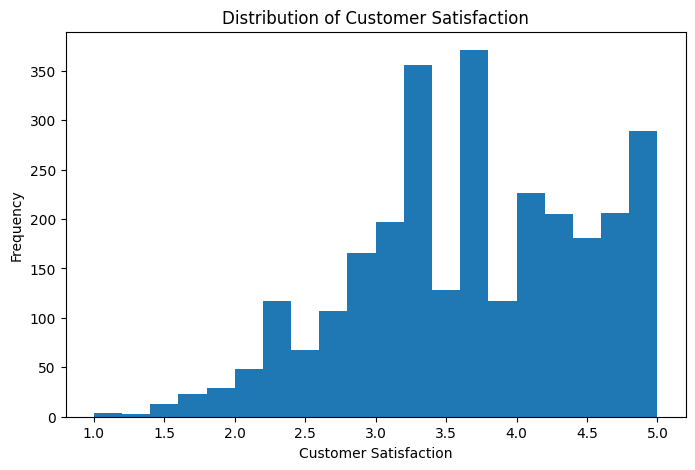

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Customer_Satisfaction'].dropna(),
    bins=20
)

plt.xlabel('Customer Satisfaction')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Satisfaction')

plt.show()

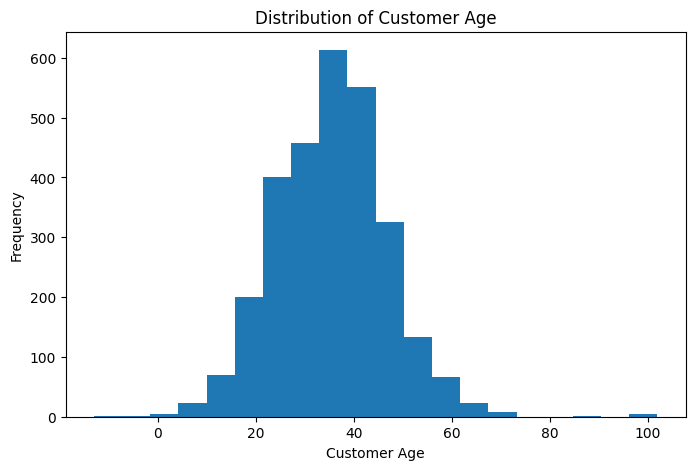

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Customer_Age'].dropna(),
    bins=20
)

plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Age')

plt.show()

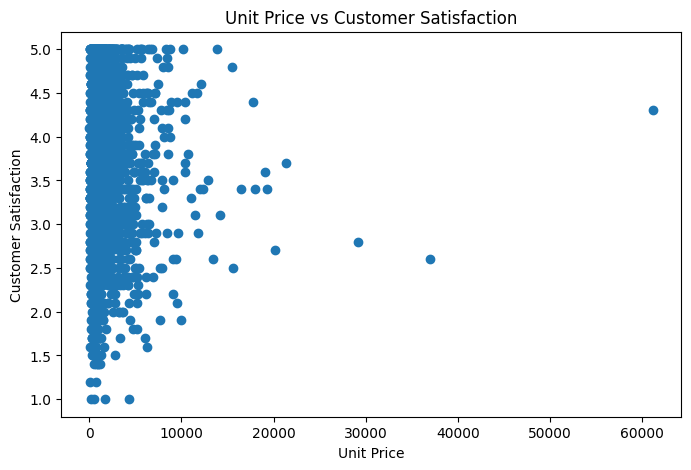

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Unit_Price'],
    df['Customer_Satisfaction']
)

plt.xlabel('Unit Price')
plt.ylabel('Customer Satisfaction')
plt.title('Unit Price vs Customer Satisfaction')

plt.show()

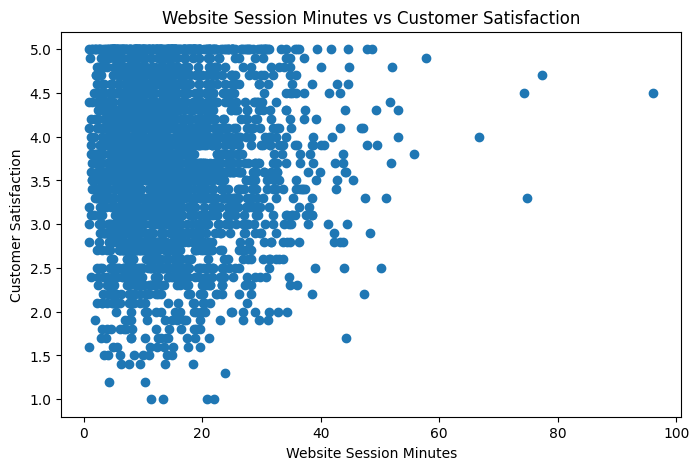

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Website_Session_Minutes'],
    df['Customer_Satisfaction']
)

plt.xlabel('Website Session Minutes')
plt.ylabel('Customer Satisfaction')
plt.title('Website Session Minutes vs Customer Satisfaction')

plt.show()

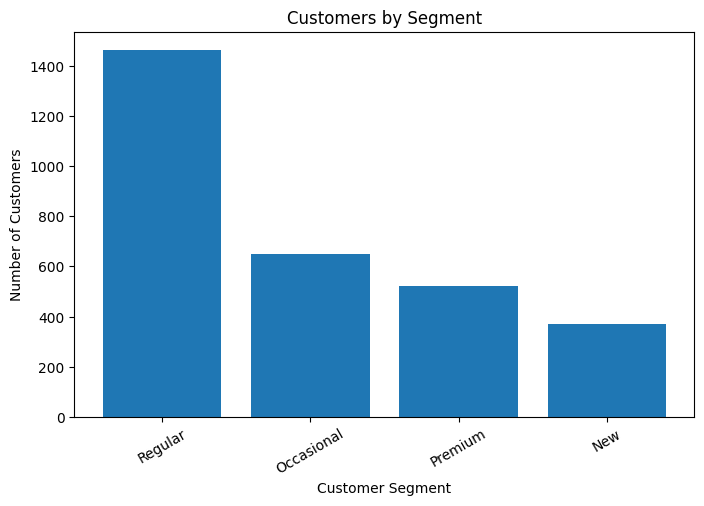

In [29]:
segment_count = df['Customer_Segment'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    segment_count.index,
    segment_count.values
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customers by Segment')

plt.xticks(rotation=30)

plt.show()

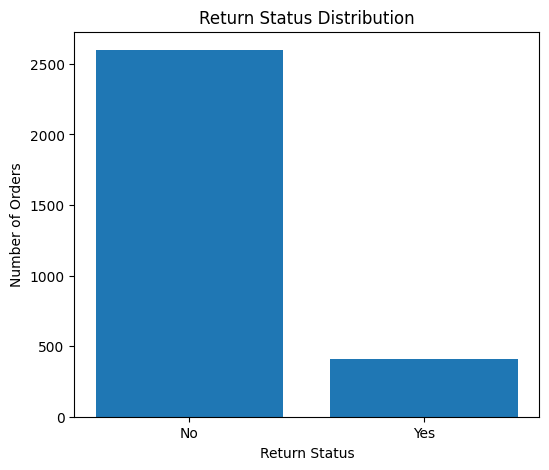

In [30]:
return_count = df['Return_Status'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    return_count.index,
    return_count.values
)

plt.xlabel('Return Status')
plt.ylabel('Number of Orders')
plt.title('Return Status Distribution')

plt.show()

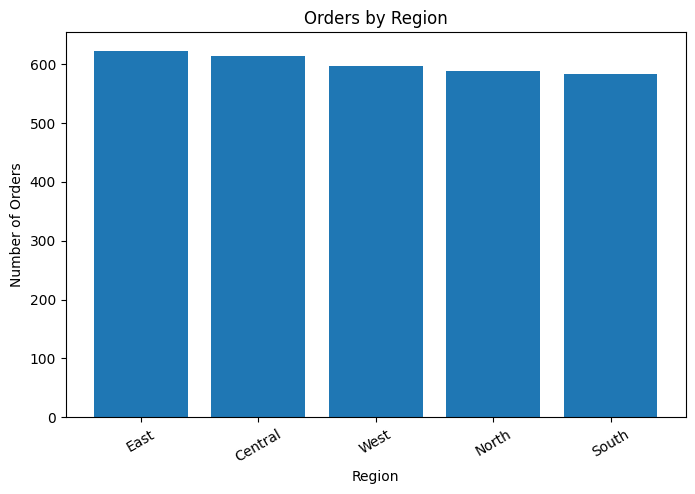

In [31]:
region_count = df['Region'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    region_count.index,
    region_count.values
)

plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.title('Orders by Region')

plt.xticks(rotation=30)

plt.show()

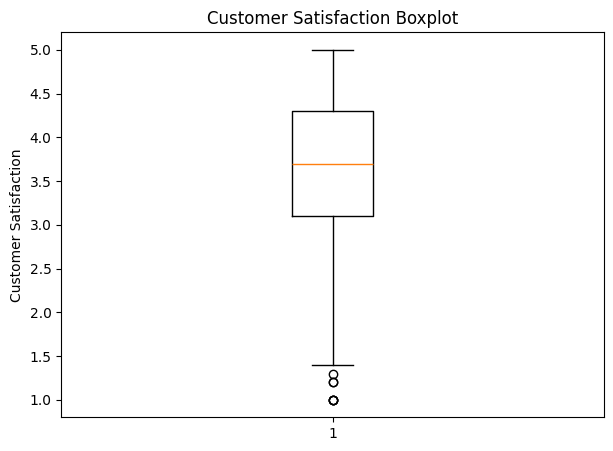

In [32]:
plt.figure(figsize=(7,5))

plt.boxplot(
    df['Customer_Satisfaction'].dropna()
)

plt.ylabel('Customer Satisfaction')
plt.title('Customer Satisfaction Boxplot')

plt.show()

In [33]:
numeric_df = df.select_dtypes(include=np.number)

In [34]:
correlation = numeric_df.corr()
correlation

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
Customer_Age,1.000000,-0.009603,-0.005537,0.021514,0.011064,-0.020332,-0.005838,0.024776,-0.005101,-0.011607,-0.009768,-0.008859,-0.002463,-0.011148,0.001058,0.000267,0.002613,-0.003362
Quantity,-0.009603,1.000000,0.005627,0.018052,-0.011264,-0.000889,-0.011621,0.003779,0.006173,-0.017558,0.003623,0.041823,0.326892,0.294361,0.329981,0.343572,0.264654,-0.009931
Unit_Price,-0.005537,0.005627,1.000000,-0.014119,-0.019047,-0.007195,0.025751,-0.004169,0.004952,0.005976,-0.022717,-0.010163,0.869996,0.725464,0.858656,0.829051,0.826038,0.004419
Discount_Pct,0.021514,0.018052,-0.014119,1.000000,-0.008679,0.025412,0.017986,-0.012707,0.001972,-0.007474,0.008713,0.014984,-0.012121,0.273965,-0.074884,-0.072163,-0.072334,-0.014710
Shipping_Days,0.011064,-0.011264,-0.019047,-0.008679,1.000000,0.010802,0.026259,0.022385,0.005347,0.001233,0.002679,0.009234,-0.025018,-0.031463,-0.025912,-0.022497,-0.030249,-0.038008
Customer_Rating,-0.020332,-0.000889,-0.007195,0.025412,0.010802,1.000000,0.022974,0.005967,0.001972,-0.004109,0.011797,-0.002543,-0.008085,0.010720,-0.010695,-0.014098,-0.002920,0.000773
Delivery_Rating,-0.005838,-0.011621,0.025751,0.017986,0.026259,0.022974,1.000000,0.009248,0.002646,0.015583,-0.022665,-0.011683,0.013611,0.009545,0.015465,0.013828,0.017214,-0.025493
Customer_Loyalty_Points,0.024776,0.003779,-0.004169,-0.012707,0.022385,0.005967,0.009248,1.000000,0.052564,-0.005094,0.004761,-0.007747,-0.004421,-0.010284,-0.005888,-0.005166,-0.006765,0.003820
Website_Session_Minutes,-0.005101,0.006173,0.004952,0.001972,0.005347,0.001972,0.002646,0.052564,1.000000,0.027495,0.002047,0.026534,0.003059,0.005541,0.005435,0.009767,-0.004309,-0.021794
Items_Viewed,-0.011607,-0.017558,0.005976,-0.007474,0.001233,-0.004109,0.015583,-0.005094,0.027495,1.000000,-0.018599,-0.016323,0.014523,0.031207,0.019050,0.013602,0.028456,-0.015143


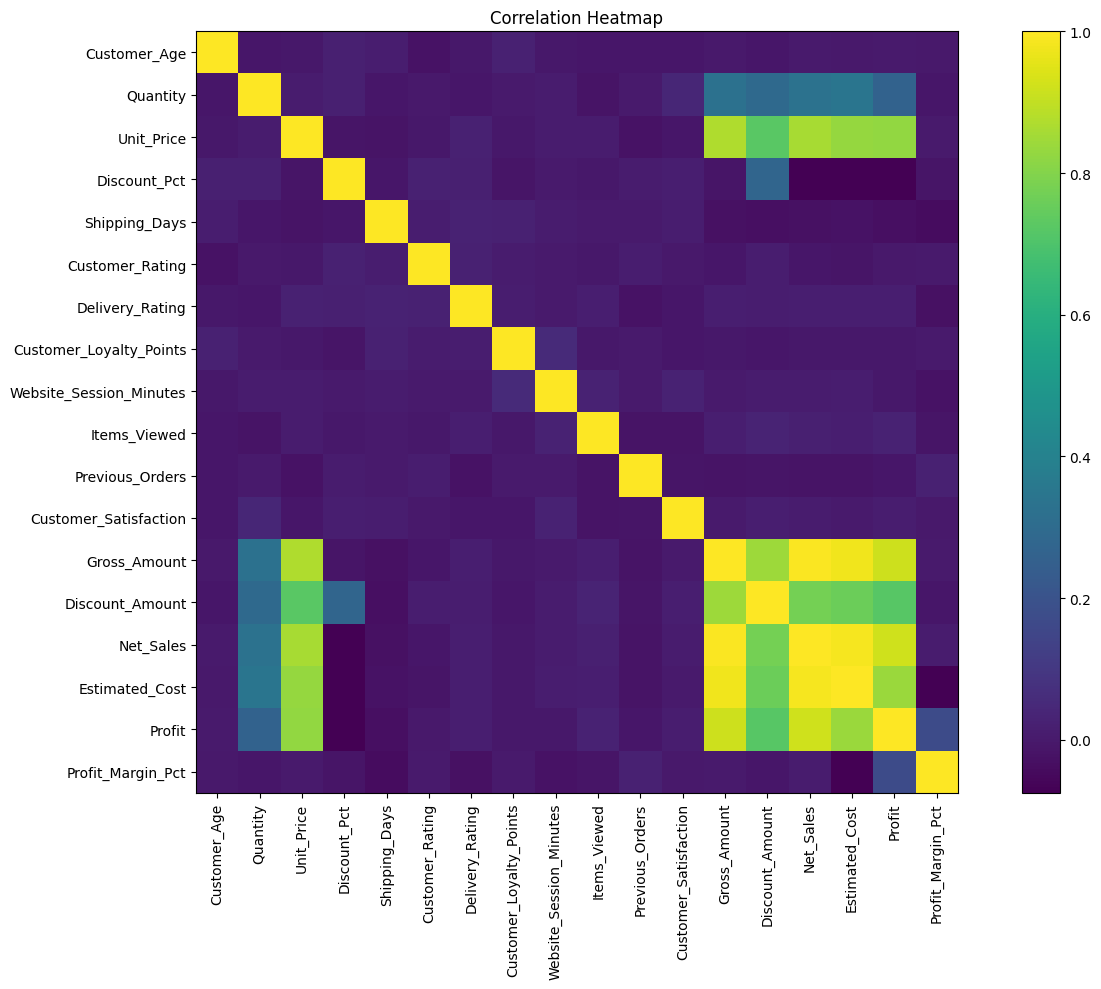

In [35]:
plt.figure(figsize=(14,10))

plt.imshow(
    correlation,
    interpolation='nearest'
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.show()

In [36]:
numeric_df.skew()

Customer_Age                0.314040
Quantity                    5.445245
Unit_Price                  9.175917
Discount_Pct                2.035084
Shipping_Days               3.305660
Customer_Rating            -0.255823
Delivery_Rating            -0.343585
Customer_Loyalty_Points     0.474449
Website_Session_Minutes     1.531912
Items_Viewed                0.398686
Previous_Orders             0.407672
Customer_Satisfaction      -0.272229
Gross_Amount               10.306803
Discount_Amount            11.373135
Net_Sales                   9.828845
Estimated_Cost              8.280526
Profit                     16.985272
Profit_Margin_Pct           0.018553
dtype: float64

In [37]:
df_linear = df.copy()

In [38]:
df_linear['Customer_Satisfaction'] = pd.to_numeric(
    df_linear['Customer_Satisfaction'],
    errors='coerce'
)

In [39]:
df_linear = df_linear.dropna(
    subset=['Customer_Satisfaction']
)

In [40]:
features = [
    'Customer_Age',
    'Customer_Segment',
    'Region',
    'Category',
    'Sales_Channel',
    'Payment_Method',
    'Device',
    'Quantity',
    'Unit_Price',
    'Discount_Pct',
    'Shipping_Days',
    'Customer_Rating',
    'Delivery_Rating',
    'Customer_Loyalty_Points',
    'Website_Session_Minutes',
    'Items_Viewed',
    'Previous_Orders',
    'Order_Status',
    'Marketing_Source'
]

In [41]:
X_linear = df_linear[features]

y_linear = df_linear['Customer_Satisfaction']

In [42]:
X_linear.head()

,Customer_Age,Customer_Segment,Region,Category,Sales_Channel,Payment_Method,Device,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Order_Status,Marketing_Source
0,44.0,Occasional,Central,Sports,Online,Debit Card,Laptop,2,361.67,0.00,6.0,2.9,5.0,1062.0,16.4,10,10,Delivered,Social Media
1,51.0,Occasional,West,Home Appliances,Online,Net Banking,Laptop,2,NaN,28.01,5.0,2.5,3.6,1252.0,23.2,9,3,Pending,Organic
2,NaN,Occasional,West,Electronics,Online,Net Banking,Laptop,1,739.05,14.30,7.0,3.9,3.7,0.0,9.1,10,6,Pending,Referral
3,38.0,Regular,North,Fashion,Mobile App,Upi,Laptop,4,7001.11,5.26,4.0,3.5,3.5,1388.0,22.7,4,4,Returned,Social Media
4,39.0,Premium,South,Electronics,Marketplace,Cash,Desktop,2,4920.89,18.72,4.0,5.0,4.6,1132.0,6.6,8,8,Delivered,Social Media


In [43]:
y_linear.head()

0    1.8
1    5.0
2    3.0
3    3.6
4    2.5
Name: Customer_Satisfaction, dtype: float64

In [44]:
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear,
    y_linear,
    test_size=0.20,
    train_size=0.80,
    random_state=35
)

In [45]:
X_train_linear.shape

(2283, 19)

In [46]:
X_test_linear.shape

(571, 19)

In [47]:
numeric_features = X_train_linear.select_dtypes(
    include=np.number
).columns

numeric_features

Index(['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct',
       'Shipping_Days', 'Customer_Rating', 'Delivery_Rating',
       'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed',
       'Previous_Orders'],
      dtype='object')

In [48]:
for column in numeric_features:
    
    median_value = X_train_linear[column].median()
    
    X_train_linear[column] = X_train_linear[column].fillna(
        median_value
    )
    
    X_test_linear[column] = X_test_linear[column].fillna(
        median_value
    )

In [49]:
categorical_features = X_train_linear.select_dtypes(
    include='object'
).columns

categorical_features

Index(['Customer_Segment', 'Region', 'Category', 'Sales_Channel',
       'Payment_Method', 'Device', 'Order_Status', 'Marketing_Source'],
      dtype='object')

In [50]:
for column in categorical_features:
    
    mode_value = X_train_linear[column].mode()[0]
    
    X_train_linear[column] = X_train_linear[column].fillna(
        mode_value
    )
    
    X_test_linear[column] = X_test_linear[column].fillna(
        mode_value
    )

In [51]:
print("NaN in X_train:", X_train_linear.isna().sum().sum())
print("NaN in X_test:", X_test_linear.isna().sum().sum())
print("NaN in y_train:", y_train_linear.isna().sum())
print("NaN in y_test:", y_test_linear.isna().sum())

NaN in X_train: 0
NaN in X_test: 0
NaN in y_train: 0
NaN in y_test: 0


In [52]:
X_train_linear = pd.get_dummies(
    X_train_linear,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_test_linear = pd.get_dummies(
    X_test_linear,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [53]:
X_train_linear, X_test_linear = X_train_linear.align(
    X_test_linear,
    join='left',
    axis=1,
    fill_value=0
)

In [54]:
X_train_linear.dtypes

Customer_Age                     float64
Quantity                           int64
Unit_Price                       float64
Discount_Pct                     float64
Shipping_Days                    float64
Customer_Rating                  float64
Delivery_Rating                  float64
Customer_Loyalty_Points          float64
Website_Session_Minutes          float64
Items_Viewed                       int64
Previous_Orders                    int64
Customer_Segment_Occasional        int64
Customer_Segment_Premium           int64
Customer_Segment_Regular           int64
Region_East                        int64
Region_North                       int64
Region_South                       int64
Region_West                        int64
Category_Books                     int64
Category_Electronics               int64
Category_Fashion                   int64
Category_Furniture                 int64
Category_Grocery                   int64
Category_Home Appliances           int64
Category_Sports 

Linear Regression

In [55]:
X_train_linear.select_dtypes(
    include='object'
).columns

Index([], dtype='object')

In [56]:
scaler_linear = StandardScaler()

In [57]:
X_train_linear_scaled = scaler_linear.fit_transform(
    X_train_linear
)

In [58]:
X_test_linear_scaled = scaler_linear.transform(
    X_test_linear
)

In [59]:
print(
    "NaN in scaled training data:",
    np.isnan(X_train_linear_scaled).sum()
)

print(
    "NaN in scaled test data:",
    np.isnan(X_test_linear_scaled).sum()
)

NaN in scaled training data: 0
NaN in scaled test data: 0


In [60]:
linear_model = LinearRegression()

In [61]:
linear_model.fit(
    X_train_linear_scaled,
    y_train_linear
)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
y_pred_linear = linear_model.predict(
    X_test_linear_scaled
)

In [63]:
y_pred_linear[:10]

array([3.82490204, 3.80764947, 3.70256576, 3.66347926, 3.72809662,
       3.72487417, 3.74288246, 3.66000683, 3.47440377, 3.80465316])

In [64]:
mae = mean_absolute_error(
    y_test_linear,
    y_pred_linear
)

mse = mean_squared_error(
    y_test_linear,
    y_pred_linear
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_linear,
    y_pred_linear
)
print("Linear Regression Performance")
print("--------------------------------")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Linear Regression Performance
--------------------------------
Mean Absolute Error: 0.6849740111268635
Mean Squared Error: 0.6929635067236743
Root Mean Squared Error: 0.8324442964689436
R2 Score: -0.005300155705141307


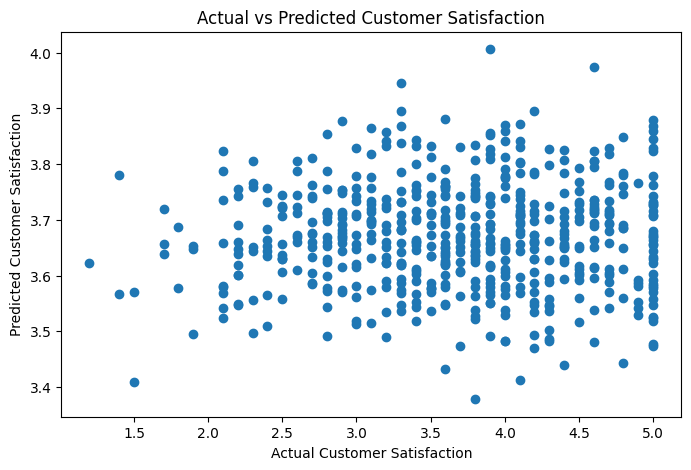

In [65]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_linear,
    y_pred_linear
)

plt.xlabel('Actual Customer Satisfaction')
plt.ylabel('Predicted Customer Satisfaction')
plt.title('Actual vs Predicted Customer Satisfaction')

plt.show()

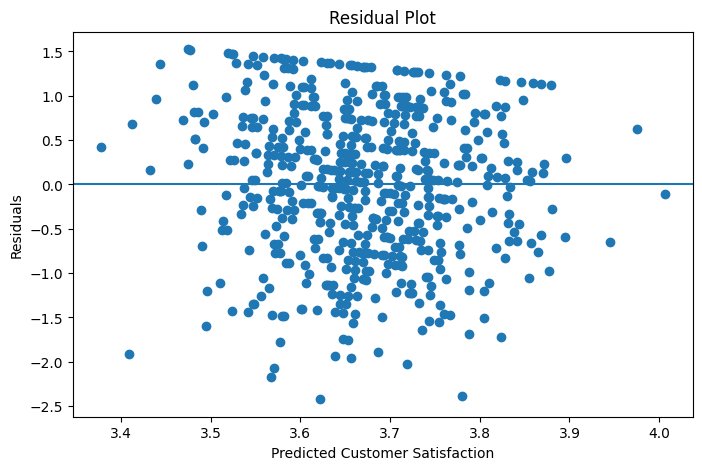

In [66]:
residuals = y_test_linear - y_pred_linear

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_linear,
    residuals
)

plt.axhline(y=0)

plt.xlabel('Predicted Customer Satisfaction')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

Logistic Regression

In [67]:
df_logistic = df.copy()

In [68]:
df_logistic['Return_Status'] = (
    df_logistic['Return_Status']
    .astype(str)
    .str.strip()
    .str.title()
)

In [69]:
df_logistic['Return_Status'] = df_logistic['Return_Status'].map({
    'No': 0,
    'Yes': 1
})

In [70]:
df_logistic['Return_Status'].value_counts()

Return_Status
0    2598
1     407
Name: count, dtype: int64

In [71]:
df_logistic = df_logistic.dropna(
    subset=['Return_Status']
)

In [72]:
X_logistic = df_logistic[features]

y_logistic = df_logistic['Return_Status']

In [73]:
X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(
    X_logistic,
    y_logistic,
    test_size=0.20,
    train_size=0.80,
    random_state=34,
    stratify=y_logistic
)

In [74]:
numeric_features_logistic = X_train_logistic.select_dtypes(
    include=np.number
).columns

In [75]:
for column in numeric_features_logistic:
    
    median_value = X_train_logistic[column].median()
    
    X_train_logistic[column] = X_train_logistic[column].fillna(
        median_value
    )
    
    X_test_logistic[column] = X_test_logistic[column].fillna(
        median_value
    )

In [76]:
categorical_features_logistic = X_train_logistic.select_dtypes(
    include='object'
).columns

In [77]:
for column in categorical_features_logistic:
    
    mode_value = X_train_logistic[column].mode()[0]
    
    X_train_logistic[column] = X_train_logistic[column].fillna(
        mode_value
    )
    
    X_test_logistic[column] = X_test_logistic[column].fillna(
        mode_value
    )

In [78]:
print("NaN in X_train:", X_train_logistic.isna().sum().sum())
print("NaN in X_test:", X_test_logistic.isna().sum().sum())
print("NaN in y_train:", y_train_logistic.isna().sum())
print("NaN in y_test:", y_test_logistic.isna().sum())

NaN in X_train: 0
NaN in X_test: 0
NaN in y_train: 0
NaN in y_test: 0


In [79]:
X_train_logistic = pd.get_dummies(
    X_train_logistic,
    columns=categorical_features_logistic,
    drop_first=True,
    dtype=int
)

X_test_logistic = pd.get_dummies(
    X_test_logistic,
    columns=categorical_features_logistic,
    drop_first=True,
    dtype=int
)

In [80]:
X_train_logistic, X_test_logistic = X_train_logistic.align(
    X_test_logistic,
    join='left',
    axis=1,
    fill_value=0
)

In [81]:
X_train_logistic.select_dtypes(
    include='object'
).columns


Index([], dtype='object')

In [82]:
scaler_logistic = StandardScaler()

In [83]:
X_train_logistic_scaled = scaler_logistic.fit_transform(
    X_train_logistic
)

In [84]:
X_test_logistic_scaled = scaler_logistic.transform(
    X_test_logistic
)

In [85]:
print(
    "NaN in scaled train:",
    np.isnan(X_train_logistic_scaled).sum()
)

print(
    "NaN in scaled test:",
    np.isnan(X_test_logistic_scaled).sum()
)

NaN in scaled train: 0
NaN in scaled test: 0


In [86]:
logistic_model = LogisticRegression(
    max_iter=1000
)

In [87]:
logistic_model.fit(
    X_train_logistic_scaled,
    y_train_logistic
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [88]:
y_pred_logistic = logistic_model.predict(
    X_test_logistic_scaled
)

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

In [90]:
logistic_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

logistic_model_balanced.fit(
    X_train_logistic_scaled,
    y_train_logistic
)

y_pred_logistic_balanced = logistic_model_balanced.predict(
    X_test_logistic_scaled
)

In [91]:
accuracy = accuracy_score(
    y_test_logistic,
    y_pred_logistic_balanced
)

precision = precision_score(
    y_test_logistic,
    y_pred_logistic_balanced
)

recall = recall_score(
    y_test_logistic,
    y_pred_logistic_balanced
)

f1 = f1_score(
    y_test_logistic,
    y_pred_logistic_balanced
)

print("Logistic Regression Performance")
print("--------------------------------")

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

print("Precision:", precision)
print("Precision Percentage:", precision * 100, "%")

print("Recall:", recall)
print("Recall Percentage:", recall * 100, "%")

print("F1 Score:", f1)
print("F1 Score Percentage:", f1 * 100, "%")

Logistic Regression Performance
--------------------------------
Accuracy: 0.56738768718802
Accuracy Percentage: 56.738768718802 %
Precision: 0.13765182186234817
Precision Percentage: 13.765182186234817 %
Recall: 0.41975308641975306
Recall Percentage: 41.9753086419753 %
F1 Score: 0.2073170731707317
F1 Score Percentage: 20.73170731707317 %


In [92]:
cm = confusion_matrix(
    y_test_logistic,
    y_pred_logistic
)

cm

array([[517,   3],
       [ 81,   0]])

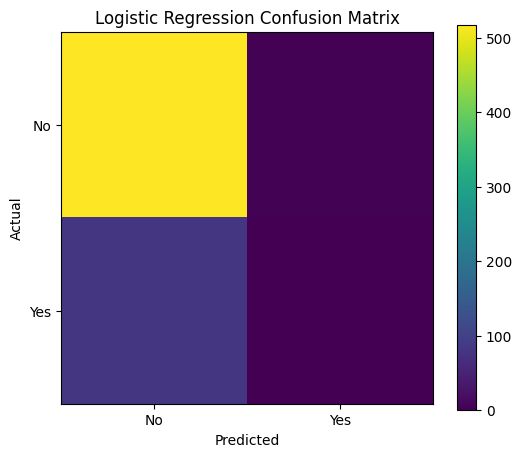

In [93]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ['No', 'Yes']
)

plt.yticks(
    [0, 1],
    ['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Logistic Regression Confusion Matrix')

plt.show()

In [94]:
print(
    classification_report(
        y_test_logistic,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       520
           1       0.00      0.00      0.00        81

    accuracy                           0.86       601
   macro avg       0.43      0.50      0.46       601
weighted avg       0.75      0.86      0.80       601



In [95]:
y_prob_logistic = logistic_model_balanced.predict_proba(
    X_test_logistic_scaled
)[:, 1]

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test_logistic,
    y_prob_logistic
)

auc_logistic = roc_auc_score(
    y_test_logistic,
    y_prob_logistic
)

print("Logistic Regression ROC-AUC")
print("---------------------------")
print("AUC:", auc_logistic)

Logistic Regression ROC-AUC
---------------------------
AUC: 0.48414055080721746


KNN

In [96]:
from sklearn.neighbors import KNeighborsClassifier

In [97]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='euclidean'
)

In [98]:
knn_model.fit(
    X_train_logistic_scaled,
    y_train_logistic
)

print("KNN Classification model trained successfully!")

KNN Classification model trained successfully!


In [99]:
y_pred_knn = knn_model.predict(
    X_test_logistic_scaled
)

print("KNN predictions generated successfully!")

KNN predictions generated successfully!


In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(
    y_test_logistic,
    y_pred_knn
)

precision_knn = precision_score(
    y_test_logistic,
    y_pred_knn
)

recall_knn = recall_score(
    y_test_logistic,
    y_pred_knn
)

f1_knn = f1_score(
    y_test_logistic,
    y_pred_knn
)

print("KNN Classification Performance")
print("--------------------------------")

print("Accuracy:", accuracy_knn)
print("Accuracy Percentage:", accuracy_knn * 100, "%")

print("Precision:", precision_knn)
print("Precision Percentage:", precision_knn * 100, "%")

print("Recall:", recall_knn)
print("Recall Percentage:", recall_knn * 100, "%")

print("F1 Score:", f1_knn)
print("F1 Score Percentage:", f1_knn * 100, "%")

KNN Classification Performance
--------------------------------
Accuracy: 0.8502495840266223
Accuracy Percentage: 85.02495840266224 %
Precision: 0.09090909090909091
Precision Percentage: 9.090909090909092 %
Recall: 0.012345679012345678
Recall Percentage: 1.2345679012345678 %
F1 Score: 0.021739130434782608
F1 Score Percentage: 2.1739130434782608 %


In [101]:
cm_knn = confusion_matrix(
    y_test_logistic,
    y_pred_knn
)

cm_knn

array([[510,  10],
       [ 80,   1]])

In [102]:
print(
    classification_report(
        y_test_logistic,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

           0       0.86      0.98      0.92       520
           1       0.09      0.01      0.02        81

    accuracy                           0.85       601
   macro avg       0.48      0.50      0.47       601
weighted avg       0.76      0.85      0.80       601



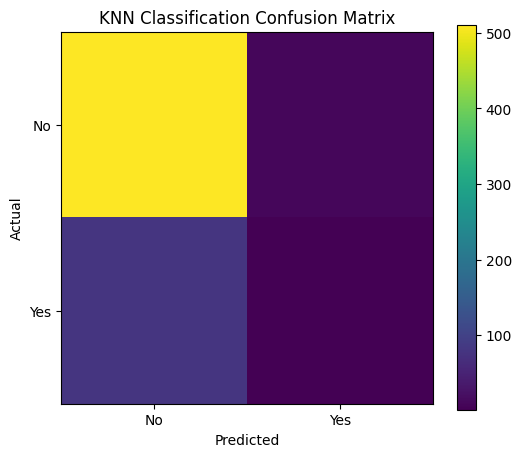

In [103]:
plt.figure(figsize=(6,5))

plt.imshow(cm_knn)

plt.colorbar()

plt.xticks(
    [0, 1],
    ['No', 'Yes']
)

plt.yticks(
    [0, 1],
    ['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('KNN Classification Confusion Matrix')

plt.show()

In [104]:
y_prob_knn = knn_model.predict_proba(
    X_test_logistic_scaled
)[:, 1]

fpr_knn, tpr_knn, thresholds_knn = roc_curve(
    y_test_logistic,
    y_prob_knn
)

auc_knn = roc_auc_score(
    y_test_logistic,
    y_prob_knn
)

print("KNN ROC-AUC")
print("-----------")
print("AUC:", auc_knn)

KNN ROC-AUC
-----------
AUC: 0.5220322886989553


Decision Tree Classifier

In [105]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=34
)

In [106]:
decision_tree_model.fit(
    X_train_logistic,
    y_train_logistic
)

print("Decision Tree Classification model trained successfully!")

Decision Tree Classification model trained successfully!


In [107]:
y_pred_dt = decision_tree_model.predict(
    X_test_logistic
)

print("Decision Tree predictions generated successfully!")

Decision Tree predictions generated successfully!


In [108]:
accuracy_dt = accuracy_score(
    y_test_logistic,
    y_pred_dt
)

precision_dt = precision_score(
    y_test_logistic,
    y_pred_dt
)

recall_dt = recall_score(
    y_test_logistic,
    y_pred_dt
)

f1_dt = f1_score(
    y_test_logistic,
    y_pred_dt
)

print("Decision Tree Classification Performance")
print("-----------------------------------------")

print("Accuracy:", accuracy_dt)
print("Accuracy Percentage:", accuracy_dt * 100, "%")

print("Precision:", precision_dt)
print("Precision Percentage:", precision_dt * 100, "%")

print("Recall:", recall_dt)
print("Recall Percentage:", recall_dt * 100, "%")

print("F1 Score:", f1_dt)
print("F1 Score Percentage:", f1_dt * 100, "%")

Decision Tree Classification Performance
-----------------------------------------
Accuracy: 0.7504159733777038
Accuracy Percentage: 75.04159733777038 %
Precision: 0.14432989690721648
Precision Percentage: 14.432989690721648 %
Recall: 0.1728395061728395
Recall Percentage: 17.28395061728395 %
F1 Score: 0.15730337078651685
F1 Score Percentage: 15.730337078651685 %


In [109]:
cm_dt = confusion_matrix(
    y_test_logistic,
    y_pred_dt
)

cm_dt

array([[437,  83],
       [ 67,  14]])

In [110]:
print(
    classification_report(
        y_test_logistic,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.87      0.84      0.85       520
           1       0.14      0.17      0.16        81

    accuracy                           0.75       601
   macro avg       0.51      0.51      0.51       601
weighted avg       0.77      0.75      0.76       601



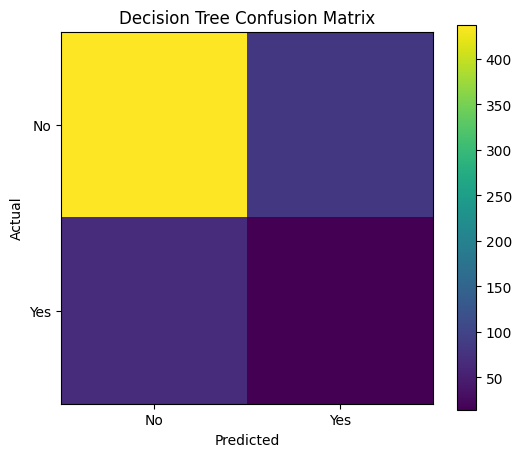

In [111]:
plt.figure(figsize=(6,5))

plt.imshow(cm_dt)

plt.colorbar()

plt.xticks(
    [0, 1],
    ['No', 'Yes']
)

plt.yticks(
    [0, 1],
    ['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Decision Tree Confusion Matrix')

plt.show()

In [112]:
y_prob_dt = decision_tree_model.predict_proba(
    X_test_logistic
)[:, 1]

fpr_dt, tpr_dt, thresholds_dt = roc_curve(
    y_test_logistic,
    y_prob_dt
)

auc_dt = roc_auc_score(
    y_test_logistic,
    y_prob_dt
)

print("Decision Tree ROC-AUC")
print("---------------------")
print("AUC:", auc_dt)

Decision Tree ROC-AUC
---------------------
AUC: 0.5066120607787274


In [113]:
model_comparison = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy,
        accuracy_knn,
        accuracy_dt
    ]
})

model_comparison

,Algorithm,Accuracy
0,Logistic Regression,0.567388
1,KNN,0.850250
2,Decision Tree,0.750416


In [114]:
model_comparison['Accuracy Percentage'] = (
    model_comparison['Accuracy'] * 100
)
model_comparison


,Algorithm,Accuracy,Accuracy Percentage
0,Logistic Regression,0.567388,56.738769
1,KNN,0.850250,85.024958
2,Decision Tree,0.750416,75.041597


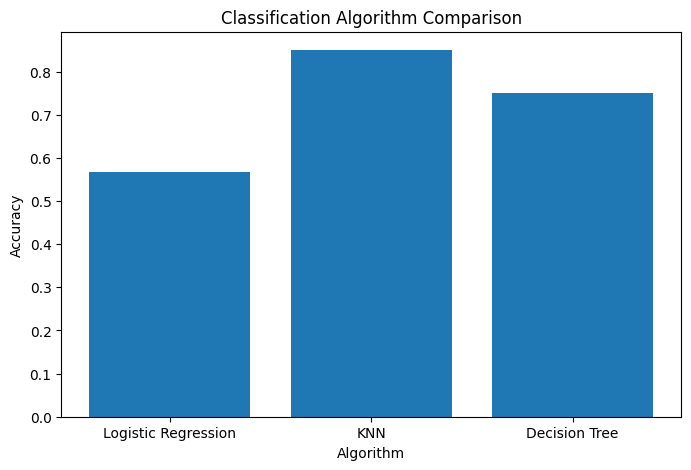

In [115]:
plt.figure(figsize=(8,5))

plt.bar(
    model_comparison['Algorithm'],
    model_comparison['Accuracy']
)

plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.title('Classification Algorithm Comparison')

plt.show()

Random Forest Classifier

In [116]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [117]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=34
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [118]:
random_forest_model.fit(
    X_train_logistic,
    y_train_logistic
)

print("Random Forest Classification model trained successfully!")

Random Forest Classification model trained successfully!


In [119]:
y_pred_rf = random_forest_model.predict(
    X_test_logistic
)

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [120]:
accuracy_rf = accuracy_score(
    y_test_logistic,
    y_pred_rf
)

precision_rf = precision_score(
    y_test_logistic,
    y_pred_rf
)

recall_rf = recall_score(
    y_test_logistic,
    y_pred_rf
)

f1_rf = f1_score(
    y_test_logistic,
    y_pred_rf
)

print("Random Forest Classification Performance")
print("-----------------------------------------")

print("Accuracy:", accuracy_rf)
print("Accuracy Percentage:", accuracy_rf * 100, "%")

print("Precision:", precision_rf)
print("Precision Percentage:", precision_rf * 100, "%")

print("Recall:", recall_rf)
print("Recall Percentage:", recall_rf * 100, "%")

print("F1 Score:", f1_rf)
print("F1 Score Percentage:", f1_rf * 100, "%")

Random Forest Classification Performance
-----------------------------------------
Accuracy: 0.8668885191347754
Accuracy Percentage: 86.68885191347754 %
Precision: 1.0
Precision Percentage: 100.0 %
Recall: 0.012345679012345678
Recall Percentage: 1.2345679012345678 %
F1 Score: 0.024390243902439025
F1 Score Percentage: 2.4390243902439024 %


In [121]:
print(
    classification_report(
        y_test_logistic,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       520
           1       1.00      0.01      0.02        81

    accuracy                           0.87       601
   macro avg       0.93      0.51      0.48       601
weighted avg       0.88      0.87      0.81       601



In [122]:
y_prob_rf = random_forest_model.predict_proba(
    X_test_logistic
)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test_logistic,
    y_prob_rf
)

auc_rf = roc_auc_score(
    y_test_logistic,
    y_prob_rf
)

print("Random Forest ROC-AUC")
print("---------------------")
print("AUC:", auc_rf)

Random Forest ROC-AUC
---------------------
AUC: 0.5082383665716999


Bagging Classifier

In [123]:
from sklearn.ensemble import BaggingClassifier

In [124]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=34),
    n_estimators=100,
    random_state=34
)

bagging_model.fit(
    X_train_logistic,
    y_train_logistic
)

y_pred_bagging = bagging_model.predict(
    X_test_logistic
)

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_bagging = accuracy_score(
    y_test_logistic,
    y_pred_bagging
)

precision_bagging = precision_score(
    y_test_logistic,
    y_pred_bagging,
    zero_division=0
)

recall_bagging = recall_score(
    y_test_logistic,
    y_pred_bagging,
    zero_division=0
)

f1_bagging = f1_score(
    y_test_logistic,
    y_pred_bagging,
    zero_division=0
)

print("Bagging Classifier Performance")
print("------------------------------")
print("Accuracy:", accuracy_bagging)
print("Accuracy Percentage:", accuracy_bagging * 100, "%")
print("Precision:", precision_bagging)
print("Precision Percentage:", precision_bagging * 100, "%")
print("Recall:", recall_bagging)
print("Recall Percentage:", recall_bagging * 100, "%")
print("F1 Score:", f1_bagging)
print("F1 Score Percentage:", f1_bagging * 100, "%")

Bagging Classifier Performance
------------------------------
Accuracy: 0.8635607321131448
Accuracy Percentage: 86.35607321131448 %
Precision: 0.3333333333333333
Precision Percentage: 33.33333333333333 %
Recall: 0.012345679012345678
Recall Percentage: 1.2345679012345678 %
F1 Score: 0.023809523809523808
F1 Score Percentage: 2.380952380952381 %


In [126]:
from sklearn.metrics import confusion_matrix

cm_bagging = confusion_matrix(
    y_test_logistic,
    y_pred_bagging
)

print("Bagging Classifier Confusion Matrix")
print("-----------------------------------")
print(cm_bagging)

Bagging Classifier Confusion Matrix
-----------------------------------
[[518   2]
 [ 80   1]]


In [127]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_bagging = bagging_model.predict_proba(
    X_test_logistic
)[:, 1]

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test_logistic,
    y_prob_bagging
)

auc_bagging = roc_auc_score(
    y_test_logistic,
    y_prob_bagging
)

print("Bagging Classifier ROC-AUC")
print("--------------------------")
print("AUC:", auc_bagging)

Bagging Classifier ROC-AUC
--------------------------
AUC: 0.5048314339981006


Gradient Boosting Classifier

In [128]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=34
)

print("Gradient Boosting model created successfully!")

Gradient Boosting model created successfully!


In [129]:
gradient_boosting_model.fit(
    X_train_logistic,
    y_train_logistic
)

print("Gradient Boosting Classification model trained successfully!")

Gradient Boosting Classification model trained successfully!


In [130]:
y_pred_gb = gradient_boosting_model.predict(
    X_test_logistic
)

print("Gradient Boosting predictions generated successfully!")

Gradient Boosting predictions generated successfully!


In [131]:
from sklearn.utils.class_weight import compute_sample_weight

In [132]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_logistic
)

gradient_boosting_model_balanced = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=34
)

gradient_boosting_model_balanced.fit(
    X_train_logistic,
    y_train_logistic,
    sample_weight=sample_weights
)

print("Balanced Gradient Boosting model trained successfully!")

Balanced Gradient Boosting model trained successfully!


In [133]:
y_pred_gb_balanced = gradient_boosting_model_balanced.predict(
    X_test_logistic
)

print("Balanced Gradient Boosting predictions generated successfully!")

Balanced Gradient Boosting predictions generated successfully!


In [134]:
print("Actual values:")
print(y_test_logistic.value_counts())

print("\nPredicted values:")
print(pd.Series(y_pred_gb_balanced).value_counts())

Actual values:
Return_Status
0    520
1     81
Name: count, dtype: int64

Predicted values:
0    443
1    158
Name: count, dtype: int64


In [135]:
accuracy_gb_balanced = accuracy_score(
    y_test_logistic,
    y_pred_gb_balanced
)

precision_gb_balanced = precision_score(
    y_test_logistic,
    y_pred_gb_balanced,
    zero_division=0
)

recall_gb_balanced = recall_score(
    y_test_logistic,
    y_pred_gb_balanced,
    zero_division=0
)

f1_gb_balanced = f1_score(
    y_test_logistic,
    y_pred_gb_balanced,
    zero_division=0
)

print("Balanced Gradient Boosting Performance")
print("---------------------------------------")

print("Accuracy:", accuracy_gb_balanced)
print("Accuracy Percentage:", accuracy_gb_balanced * 100, "%")

print("Precision:", precision_gb_balanced)
print("Precision Percentage:", precision_gb_balanced * 100, "%")

print("Recall:", recall_gb_balanced)
print("Recall Percentage:", recall_gb_balanced * 100, "%")

print("F1 Score:", f1_gb_balanced)
print("F1 Score Percentage:", f1_gb_balanced * 100, "%")

Balanced Gradient Boosting Performance
---------------------------------------
Accuracy: 0.6622296173044925
Accuracy Percentage: 66.22296173044924 %
Precision: 0.11392405063291139
Precision Percentage: 11.39240506329114 %
Recall: 0.2222222222222222
Recall Percentage: 22.22222222222222 %
F1 Score: 0.1506276150627615
F1 Score Percentage: 15.062761506276152 %


In [136]:
print(
    classification_report(
        y_test_logistic,
        y_pred_gb_balanced,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.86      0.73      0.79       520
           1       0.11      0.22      0.15        81

    accuracy                           0.66       601
   macro avg       0.49      0.48      0.47       601
weighted avg       0.76      0.66      0.70       601



In [137]:
y_prob_gb = gradient_boosting_model_balanced.predict_proba(
    X_test_logistic
)[:, 1]

fpr_gb, tpr_gb, thresholds_gb = roc_curve(
    y_test_logistic,
    y_prob_gb
)

auc_gb = roc_auc_score(
    y_test_logistic,
    y_prob_gb
)

print("Gradient Boosting ROC-AUC")
print("-------------------------")
print("AUC:", auc_gb)

Gradient Boosting ROC-AUC
-------------------------
AUC: 0.47989078822412157


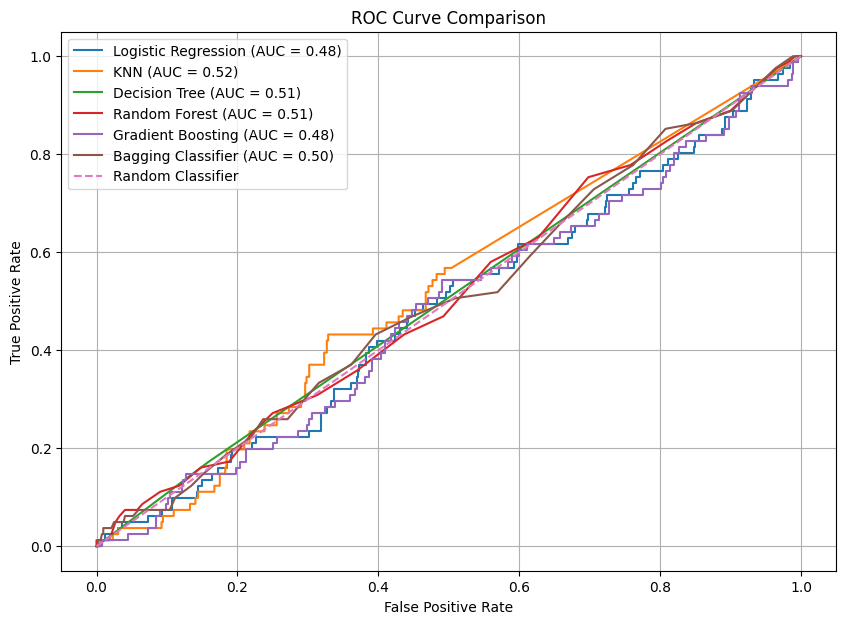

In [138]:
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label="Logistic Regression (AUC = {:.2f})".format(auc_logistic)
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label="KNN (AUC = {:.2f})".format(auc_knn)
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label="Decision Tree (AUC = {:.2f})".format(auc_dt)
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest (AUC = {:.2f})".format(auc_rf)
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label="Gradient Boosting (AUC = {:.2f})".format(auc_gb)
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label="Bagging Classifier (AUC = {:.2f})".format(auc_bagging)
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()
plt.show()

In [139]:
model_comparison = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    
    'Accuracy': [
        accuracy,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf,
        accuracy_gb_balanced
    ],
    
    'Precision': [
        precision,
        precision_knn,
        precision_dt,
        precision_rf,
        precision_gb_balanced
    ],
    
    'Recall': [
        recall,
        recall_knn,
        recall_dt,
        recall_rf,
        recall_gb_balanced
    ],
    
    'F1 Score': [
        f1,
        f1_knn,
        f1_dt,
        f1_rf,
        f1_gb_balanced
    ]
})

model_comparison

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.567388,0.137652,0.419753,0.207317
1,KNN,0.850250,0.090909,0.012346,0.021739
2,Decision Tree,0.750416,0.144330,0.172840,0.157303
3,Random Forest,0.866889,1.000000,0.012346,0.024390
4,Gradient Boosting,0.662230,0.113924,0.222222,0.150628


AdaBoost Classifier

In [140]:
from sklearn.ensemble import AdaBoostClassifier

In [141]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_logistic
)

adaboost_model_balanced = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=34
)

adaboost_model_balanced.fit(
    X_train_logistic,
    y_train_logistic,
    sample_weight=sample_weights
)

y_pred_adaboost_balanced = adaboost_model_balanced.predict(
    X_test_logistic
)

In [142]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_adaboost_balanced = accuracy_score(
    y_test_logistic,
    y_pred_adaboost_balanced
)

precision_adaboost_balanced = precision_score(
    y_test_logistic,
    y_pred_adaboost_balanced,
    zero_division=0
)

recall_adaboost_balanced = recall_score(
    y_test_logistic,
    y_pred_adaboost_balanced,
    zero_division=0
)

f1_adaboost_balanced = f1_score(
    y_test_logistic,
    y_pred_adaboost_balanced,
    zero_division=0
)

print("Balanced AdaBoost Classification Performance")
print("---------------------------------------------")
print("Accuracy:", accuracy_adaboost_balanced)
print("Accuracy Percentage:", accuracy_adaboost_balanced * 100, "%")
print("Precision:", precision_adaboost_balanced)
print("Precision Percentage:", precision_adaboost_balanced * 100, "%")
print("Recall:", recall_adaboost_balanced)
print("Recall Percentage:", recall_adaboost_balanced * 100, "%")
print("F1 Score:", f1_adaboost_balanced)
print("F1 Score Percentage:", f1_adaboost_balanced * 100, "%")

Balanced AdaBoost Classification Performance
---------------------------------------------
Accuracy: 0.5174708818635607
Accuracy Percentage: 51.74708818635607 %
Precision: 0.1505016722408027
Precision Percentage: 15.050167224080269 %
Recall: 0.5555555555555556
Recall Percentage: 55.55555555555556 %
F1 Score: 0.23684210526315788
F1 Score Percentage: 23.684210526315788 %


In [143]:
from sklearn.metrics import confusion_matrix

cm_adaboost = confusion_matrix(
    y_test_logistic,
    y_pred_adaboost_balanced
)

print("AdaBoost Confusion Matrix")
print("-------------------------")
print(cm_adaboost)

AdaBoost Confusion Matrix
-------------------------
[[266 254]
 [ 36  45]]


In [144]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_adaboost = adaboost_model_balanced.predict_proba(
    X_test_logistic
)[:, 1]

fpr_adaboost, tpr_adaboost, thresholds_adaboost = roc_curve(
    y_test_logistic,
    y_prob_adaboost
)

auc_adaboost = roc_auc_score(
    y_test_logistic,
    y_prob_adaboost
)

print("AdaBoost ROC-AUC")
print("----------------")
print("AUC:", auc_adaboost)

AdaBoost ROC-AUC
----------------
AUC: 0.5471866096866096


In [145]:
model_comparison = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Bagging Classifier',
        'Gradient Boosting',
        'AdaBoost'
    ],

    'Accuracy': [
        accuracy,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf,
        accuracy_bagging,
        accuracy_gb_balanced,
        accuracy_adaboost_balanced
    ],

    'Precision': [
        precision,
        precision_knn,
        precision_dt,
        precision_rf,
        precision_bagging,
        precision_gb_balanced,
        precision_adaboost_balanced
    ],

    'Recall': [
        recall,
        recall_knn,
        recall_dt,
        recall_rf,
        recall_bagging,
        recall_gb_balanced,
        recall_adaboost_balanced
    ],

    'F1 Score': [
        f1,
        f1_knn,
        f1_dt,
        f1_rf,
        f1_bagging,
        f1_gb_balanced,
        f1_adaboost_balanced
    ]
})

model_comparison

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.567388,0.137652,0.419753,0.207317
1,KNN,0.850250,0.090909,0.012346,0.021739
2,Decision Tree,0.750416,0.144330,0.172840,0.157303
3,Random Forest,0.866889,1.000000,0.012346,0.024390
4,Bagging Classifier,0.863561,0.333333,0.012346,0.023810
5,Gradient Boosting,0.662230,0.113924,0.222222,0.150628
6,AdaBoost,0.517471,0.150502,0.555556,0.236842


SVC

In [146]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    probability=True,
    random_state=34
)

svc_model.fit(
    X_train_logistic_scaled,
    y_train_logistic
)

y_pred_svc = svc_model.predict(
    X_test_logistic_scaled
)

In [147]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_svc = accuracy_score(y_test_logistic, y_pred_svc)
precision_svc = precision_score(y_test_logistic, y_pred_svc, zero_division=0)
recall_svc = recall_score(y_test_logistic, y_pred_svc, zero_division=0)
f1_svc = f1_score(y_test_logistic, y_pred_svc, zero_division=0)

print("SVC Performance")
print("----------------")
print("Accuracy:", accuracy_svc)
print("Accuracy Percentage:", accuracy_svc * 100, "%")
print("Precision:", precision_svc)
print("Precision Percentage:", precision_svc * 100, "%")
print("Recall:", recall_svc)
print("Recall Percentage:", recall_svc * 100, "%")
print("F1 Score:", f1_svc)
print("F1 Score Percentage:", f1_svc * 100, "%")

SVC Performance
----------------
Accuracy: 0.7221297836938436
Accuracy Percentage: 72.21297836938436 %
Precision: 0.14166666666666666
Precision Percentage: 14.166666666666666 %
Recall: 0.20987654320987653
Recall Percentage: 20.98765432098765 %
F1 Score: 0.1691542288557214
F1 Score Percentage: 16.91542288557214 %


In [148]:
from sklearn.metrics import confusion_matrix

cm_svc = confusion_matrix(
    y_test_logistic,
    y_pred_svc
)

print("SVC Confusion Matrix")
print("--------------------")
print(cm_svc)

SVC Confusion Matrix
--------------------
[[417 103]
 [ 64  17]]


In [149]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_svc = svc_model.predict_proba(
    X_test_logistic_scaled
)[:, 1]

fpr_svc, tpr_svc, thresholds_svc = roc_curve(
    y_test_logistic,
    y_prob_svc
)

auc_svc = roc_auc_score(
    y_test_logistic,
    y_prob_svc
)

print("SVC ROC-AUC")
print("-----------")
print("AUC:", auc_svc)

SVC ROC-AUC
-----------
AUC: 0.5293684710351377


In [150]:
model_comparison = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'SVC',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Bagging Classifier',
        'Gradient Boosting',
        'AdaBoost'
    ],

    'Accuracy': [
        accuracy,
        accuracy_svc,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf,
        accuracy_bagging,
        accuracy_gb_balanced,
        accuracy_adaboost_balanced
    ],

    'Precision': [
        precision,
        precision_svc,
        precision_knn,
        precision_dt,
        precision_rf,
        precision_bagging,
        precision_gb_balanced,
        precision_adaboost_balanced
    ],

    'Recall': [
        recall,
        recall_svc,
        recall_knn,
        recall_dt,
        recall_rf,
        recall_bagging,
        recall_gb_balanced,
        recall_adaboost_balanced
    ],

    'F1 Score': [
        f1,
        f1_svc,
        f1_knn,
        f1_dt,
        f1_rf,
        f1_bagging,
        f1_gb_balanced,
        f1_adaboost_balanced
    ]
})

model_comparison

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.567388,0.137652,0.419753,0.207317
1,SVC,0.722130,0.141667,0.209877,0.169154
2,KNN,0.850250,0.090909,0.012346,0.021739
3,Decision Tree,0.750416,0.144330,0.172840,0.157303
4,Random Forest,0.866889,1.000000,0.012346,0.024390
5,Bagging Classifier,0.863561,0.333333,0.012346,0.023810
6,Gradient Boosting,0.662230,0.113924,0.222222,0.150628
7,AdaBoost,0.517471,0.150502,0.555556,0.236842


DecisionTree Regressor

In [151]:
from sklearn.tree import DecisionTreeRegressor

In [152]:
X_dtr = df.drop(columns=['Unit_Price'])

y_dtr = df['Unit_Price']

In [153]:
X_dtr = X_dtr.drop(columns=[
    'Order_ID',
    'Product_ID',
    'Location_ID',
    'Sales_Person_ID',
    'Customer_ID'
], errors='ignore')

In [154]:
X_dtr = pd.get_dummies(
    X_dtr,
    drop_first=True
)

In [155]:
X_dtr = X_dtr.fillna(
    X_dtr.median(numeric_only=True)
)

X_dtr = X_dtr.fillna(0)

In [156]:
valid_rows = y_dtr.notna()

X_dtr = X_dtr.loc[valid_rows]
y_dtr = y_dtr.loc[valid_rows]

In [157]:
X_train_dtr, X_test_dtr, y_train_dtr, y_test_dtr = train_test_split(
    X_dtr,
    y_dtr,
    test_size=0.2,
    random_state=34
)

In [158]:
decision_tree_regressor = DecisionTreeRegressor(
    random_state=34
)

In [159]:
decision_tree_regressor.fit(
    X_train_dtr,
    y_train_dtr
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",34
,"max_l

In [160]:
y_pred_dtr = decision_tree_regressor.predict(
    X_test_dtr
)

In [161]:
mae_dtr = mean_absolute_error(
    y_test_dtr,
    y_pred_dtr
)

mse_dtr = mean_squared_error(
    y_test_dtr,
    y_pred_dtr
)

rmse_dtr = np.sqrt(mse_dtr)

r2_dtr = r2_score(
    y_test_dtr,
    y_pred_dtr
)

print("Decision Tree Regressor Performance")
print("-----------------------------------")
print("MAE:", mae_dtr)
print("MSE:", mse_dtr)
print("RMSE:", rmse_dtr)
print("R2 Score:", r2_dtr)

Decision Tree Regressor Performance
-----------------------------------
MAE: 252.91960548885078
MSE: 3226742.746667067
RMSE: 1796.3136548685106
R2 Score: 0.6194796037745811


RandomForest Regressor

In [162]:
from sklearn.ensemble import RandomForestRegressor

In [163]:
X_rfr = df.drop(columns=['Unit_Price'])

y_rfr = df['Unit_Price']

In [164]:
X_rfr = X_rfr.drop(columns=[
    'Order_ID',
    'Product_ID',
    'Location_ID',
    'Sales_Person_ID',
    'Customer_ID'
], errors='ignore')

In [165]:
X_rfr = pd.get_dummies(
    X_rfr,
    drop_first=True
)

In [166]:
X_rfr = X_rfr.fillna(
    X_rfr.median(numeric_only=True)
)

X_rfr = X_rfr.fillna(0)

In [167]:
valid_rows = y_rfr.notna()

X_rfr = X_rfr.loc[valid_rows]
y_rfr = y_rfr.loc[valid_rows]

In [168]:
X_train_rfr, X_test_rfr, y_train_rfr, y_test_rfr = train_test_split(
    X_rfr,
    y_rfr,
    test_size=0.2,
    random_state=34
)

In [169]:
random_forest_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=34
)

In [170]:
random_forest_regressor.fit(
    X_train_rfr,
    y_train_rfr
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [171]:
y_pred_rfr = random_forest_regressor.predict(
    X_test_rfr
)

In [172]:
mae_rfr = mean_absolute_error(
    y_test_rfr,
    y_pred_rfr
)

mse_rfr = mean_squared_error(
    y_test_rfr,
    y_pred_rfr
)

rmse_rfr = np.sqrt(mse_rfr)

r2_rfr = r2_score(
    y_test_rfr,
    y_pred_rfr
)

print("Random Forest Regressor Performance")
print("------------------------------------")
print("MAE:", mae_rfr)
print("MSE:", mse_rfr)
print("RMSE:", rmse_rfr)
print("R2 Score:", r2_rfr)

Random Forest Regressor Performance
------------------------------------
MAE: 195.21161955403085
MSE: 2243915.620121355
RMSE: 1497.9705004176
R2 Score: 0.7353815510248096
